In [3]:
import sys
sys.path.append('../d03_src/')
import vars
import synthetic as syn

import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Helvetica Light'
plt.rc('axes', unicode_minus=False)
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D

plots_dir = '../plots/'

# A Synthetic Validation

In this notebook we evaluate a synthetic validation of MIGRATE. We:

- Use as input (i.e. Infutor) a noisy version of the CBG-CBG MIGRATE matrices
- Use as contraints (i.e. Census data) aggregated of the MIGRATE matrices (when appropriate, noisy)
- Estimate via our method the underlying CBG-CBG matrix that fits the constraints based on the noisy input and compare to the MIGRATE ``ground-truth''

The code to run these experiments is on the script `d04_scripts/d04_optimization/02_Synthetic.py`. The code to process the results into the dataframes that will be read in this notebook is on the script `d04_scripts/d04_optimization/03_Evaluate-Synthetic.py`.

## Read the results

Define the directories:

In [4]:
out_files_dir = f'{vars._path_to_repo}d04_scripts/jobs/_outputs/synth/'
synthetic_dir = f'{vars._path_to_repo}d05_outputs/d06_Synthetic/'

Collect our performance metrics for the synthetic experiments:

In [5]:
quantity_dfs = {quantity: pd.read_csv(f'{synthetic_dir}performance/{quantity}.csv', header=[0,1,2]) for quantity in ['flows', 'movers', 'stayers', 'in-migration', 'in-migration_rate', 'population']}

Some plotting parameters:

In [6]:
bias_knob = 'Bias scale' #Relative overcounting (%)
quantity_plot_params = {'flows': {'label':'All flows',   'marker':'o', 'color':'tomato'},
                        'movers':{'label':'Only movers', 'marker':'s', 'color':'forestgreen'}}
quantities_to_plot = ['flows', 'movers']
noise_scales_to_plot = [0., .05, .10, .15, .2]#, .25]
min_bias_to_plot = 0.05
noise_cmap = {v: plt.colormaps['plasma_r'](plt.Normalize(min(noise_scales_to_plot), max(noise_scales_to_plot))(v)) for v in noise_scales_to_plot}
CI_alpha = 0.95 #ignored if ebar is sd
ebar = 'sd' #or sem

## Harmonizing in the Presence of Structured Multiplicative Noise

Here we investigate whether we can recover the ground truth matrix in the presence of scalers following our harmonization structure. We simulated a matrix with the exact structure of scalers we harmonize with, compute RMSEs on perturbed and inferred matrices.

In [8]:
quantity_tables = {quantity: syn.collect_tables(df, noise_family='LogNormal', noise_structure='Structured multiplicative', bias_knob='Bias scale') for quantity, df in quantity_dfs.items()}

Visualize all flows and only movers:

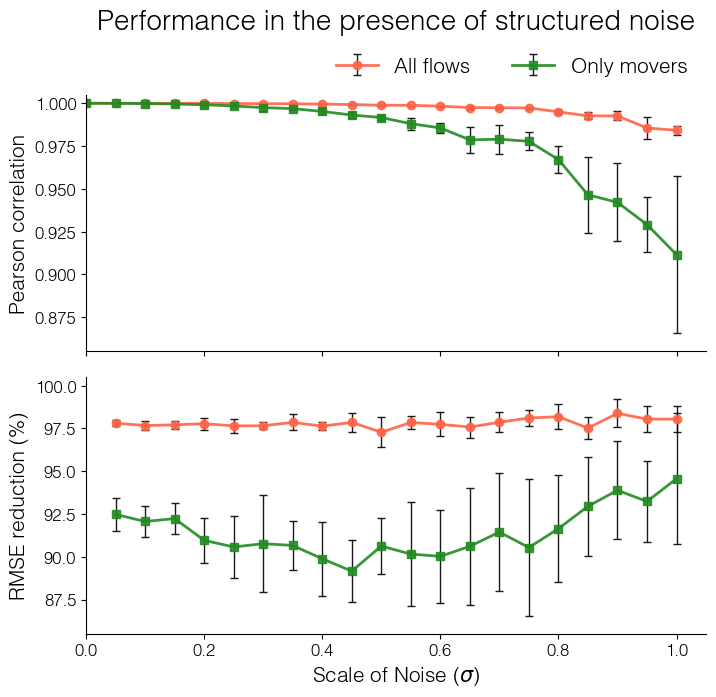

Pearson correlation             RMSE reduction (%)            
                      All flows Only movers          All flows Only movers
Noise scale                                                               
0.00                      1.000       1.000                NaN         NaN
0.05                      1.000       1.000             97.805      92.475
0.10                      1.000       1.000             97.667      92.059
0.15                      1.000       1.000             97.707      92.228
0.20                      1.000       0.999             97.775      90.961
0.25                      1.000       0.998             97.646      90.570
0.30                      1.000       0.997             97.653      90.762
0.35                      1.000       0.997             97.850      90.659
0.40                      1.000       0.995             97.632      89.881
0.45                      0.999       0.993             97.849      89.158
0.50                      0.999       0.992             97.276      90.622
0.55                      0.999       0.988             97.844      90.156
0.60                      0.998       0.986             97.743      90.022
0.65                      0.997       0.979             97.574      90.609
0.70                      0.997       0.979             97.860      91.440
0.75                      0.997       0.978             98.107      90.538
0.80                      0.995       0.967             98.185      91.640
0.85                      0.993       0.946             97.516      92.946
0.90                      0.993       0.942             98.380      93.884
0.95                      0.986       0.929             98.046      93.231
1.00                      0.984       0.912             98.043      94.558

Pearson correlation             RMSE reduction (%)            
                All flows Only movers          All flows Only movers
count              21.000      21.000             20.000      20.000
mean                0.997       0.980             97.808      91.420
std                 0.005       0.026              0.253       1.429
min                 0.984       0.912             97.276      89.158
25%                 0.997       0.978             97.651      90.562
50%                 0.999       0.992             97.790      90.862
75%                 1.000       0.998             97.906      92.290
max                 1.000       1.000             98.380      94.558

In [9]:
fig, Axes = plt.subplots(figsize=(8,7), nrows=2, sharex=True, gridspec_kw={'hspace':0.1})
df_to_display = {}
lower_limit = .855

#Plot reduction and Pearson:
for quantity in quantities_to_plot:
    for ax, metric in zip(Axes, ['Pearson correlation', 'RMSE reduction (%)']):
        series = quantity_tables[quantity]['Mean'][metric]['blockgroup'][0]
        _ = ax.errorbar(series.index, series.values,
                        yerr=stats.norm.ppf((1+CI_alpha)/2)*quantity_tables[quantity]['SEM'][metric]['blockgroup'][0] if ebar == 'SEM' else quantity_tables[quantity]['std'][metric]['blockgroup'][0],
                        color=quantity_plot_params[quantity]['color'], alpha=.9,
                        marker=quantity_plot_params[quantity]['marker'],
                        capsize=3, ecolor='k', elinewidth=1, linewidth=2,
                        label=quantity_plot_params[quantity]['label'])
        _ = ax.set_ylabel(metric, fontsize=15)
        _ = ax.set_ylim(100*lower_limit if '%' in metric else lower_limit, 100.5 if '%' in metric else 1.005)
        df_to_display[(metric, quantity_plot_params[quantity]['label'])] = series

#Configure both axes:
for ax in Axes:
    _ = ax.spines[['top', 'right']].set_visible(False)
    _ = ax.tick_params(axis='both', labelsize=12)
    _ = ax.set_xlim(0, 1.05)
_ = Axes[1].set_xlabel(r'Scale of Noise ($\sigma$)', fontsize=15)
_ = Axes[0].legend(frameon=False, fontsize=15, ncols=len(quantities_to_plot), loc='lower right', bbox_to_anchor=(1.,1.), bbox_transform=Axes[0].transAxes)
_ = Axes[0].set_title('Performance in the presence of structured noise', fontsize=20, y=1.2, va='bottom')
plt.show()

#Display summaries:
df_to_display = pd.DataFrame(df_to_display).T.sort_index().T
display(df_to_display.round(3))
display(df_to_display.describe().round(3))

## Harmonizing in the Presence of Real-World Bias and Independent Noise

We now look at cases where i.i.d. LogNormal noise is drawn per entry, and CBG-level bias is added according to a subpopulation overcounting

In [10]:
quantity_tables = {quantity: syn.collect_tables(df, noise_family='LogNormal', noise_structure='i.i.d', bias_knob='Bias scale') for quantity, df in quantity_dfs.items()}

Let's visualize for selected noise scales:

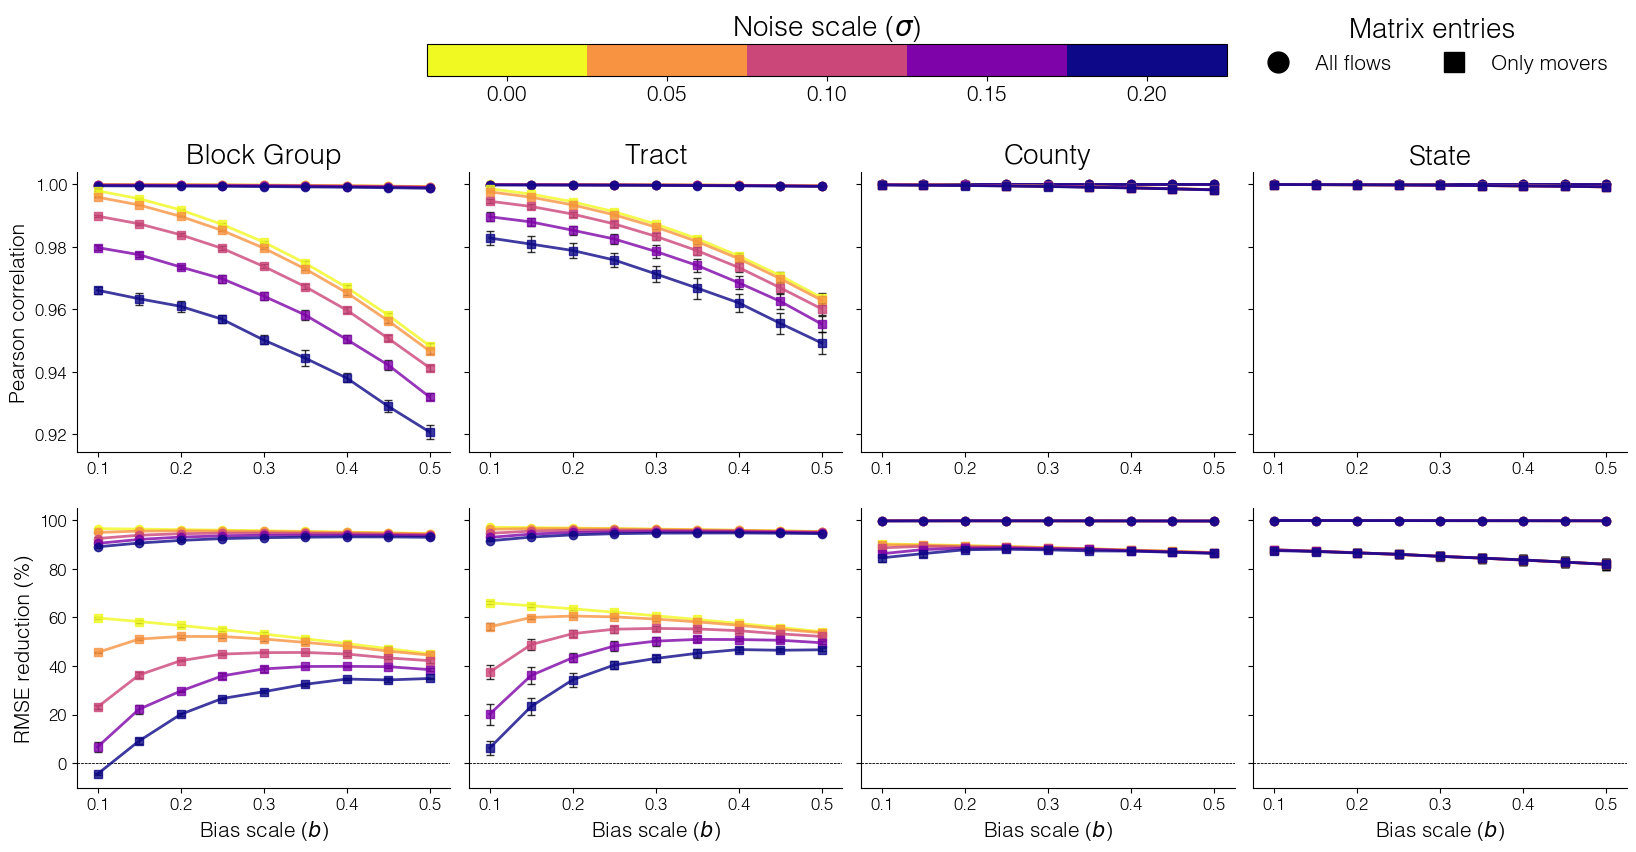

In [11]:
fig, Axes = plt.subplots(figsize=(20,8), nrows=2, ncols=4, sharey='row', gridspec_kw={'wspace':0.05, 'hspace':0.2})

#Plot reduction and Pearson for all quantities and geographic levels:
for quantity in quantities_to_plot:
    for ax_row_idx, metric in enumerate(['Pearson correlation', 'RMSE reduction (%)']):
        for ax_col_idx, geography in enumerate(['blockgroup', 'tract', 'county', 'state']):
            #Get the ax:
            ax = Axes[ax_row_idx, ax_col_idx]
            #Get the averages and error bars:
            values = quantity_tables[quantity]['Mean'][metric][geography]
            errors = stats.norm.ppf((1+CI_alpha)/2)*quantity_tables[quantity]['SEM'][metric][geography] if ebar == 'SEM' else quantity_tables[quantity]['std'][metric][geography]
            #Plot at each noise scale:
            for noise_scale in noise_scales_to_plot:
                series = values.loc[noise_scale]
                _ = ax.errorbar(series.index[series.index > min_bias_to_plot], series.values[series.index > min_bias_to_plot],
                                yerr=errors.loc[noise_scale].values[series.index > min_bias_to_plot],
                                color=noise_cmap[noise_scale], alpha=.8,
                                marker=quantity_plot_params[quantity]['marker'],
                                capsize=3, ecolor='k', elinewidth=1, linewidth=2,
                                label=quantity_plot_params[quantity]['label'],
                                zorder=1)
                
            #Include dashed line on RMSE plot:
            if 'RMSE' in metric: _ = ax.axhline(0, color='k', zorder=-1, alpha=0.9, linestyle='--', linewidth=0.5)

            #Include title on the first plot of each column (and the label on the last):
            if ax_row_idx == 0:
                _ = Axes[ax_row_idx, ax_col_idx].set_title('Block Group' if geography == 'blockgroup' else geography.capitalize(), fontsize=20)
            if ax_row_idx == Axes.shape[0]-1:
                _ = Axes[ax_row_idx, ax_col_idx].set_xlabel(r'Bias scale ($b$)', fontsize=15)

        #Label the y-axis in the first plot of each row:
        _ = Axes[ax_row_idx, 0].set_ylabel(metric, fontsize=15)

#Configure both axes:
for ax in Axes.flatten():
    _ = ax.spines[['top', 'right']].set_visible(False)
    _ = ax.tick_params(axis='both', labelsize=12)
    _ = ax.set_xlim(min_bias_to_plot + .025, .525)

# Discretized colorbar (noise scale)
cmap = ListedColormap([noise_cmap[v] for v in noise_scales_to_plot])
bounds = np.arange(len(noise_scales_to_plot) + 1)
norm = BoundaryNorm(bounds, cmap.N)
cb_ax = fig.add_axes([0.3, 1., 0.4, 0.04])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, cax=cb_ax, orientation='horizontal', ticks=np.arange(len(noise_scales_to_plot)) + 0.5)
cb.ax.set_xticklabels([f"{v:.2f}" for v in noise_scales_to_plot], ha='center', fontsize=15)
cb.ax.tick_params(which='minor', bottom=False, top=False)
_ = cb.ax.set_title(r'Noise scale ($\sigma$)', fontsize=20)

# Tiny legend for quantity markers (separate from colorbar)
handles = [Line2D([0],[0], marker=quantity_plot_params[q]['marker'], linestyle='None', label=quantity_plot_params[q]['label'], markersize=15, markerfacecolor='k', markeredgecolor='k') for q in ['flows','movers']]
_ = fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(.9, .98), ncol=2, frameon=False, title='Matrix entries', fontsize=15, title_fontsize=20)

#Save:
plt.savefig(f'{plots_dir}synthetic-simulations.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{plots_dir}synthetic-simulations.png', dpi=300, bbox_inches='tight')